### Manejo de marcas faltantes en el tiempo NaT


#### Caso 1. NO hay correspondencia entre las marcas faltantes y la frecuencia de la serie

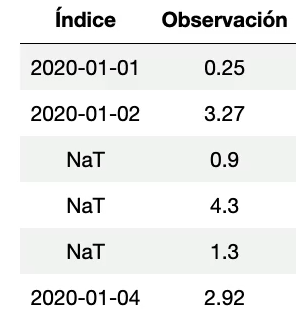

Pareciera que la frecuencia es diaria, pero hay 3 regitros ocupando el espacio que le pertenecería a una sola. EN este caso se hace una eliminación de esos registros y posteriormente se imputará con un valor diferente

In [19]:
import pandas as pd

ind = ['2020-01-01', '2020-01-02', 'NaT', 'NaT', 'NaT', '2020-01-04']
ind = pd.to_datetime(ind)
obs = [0.25, 3.27, 0.9, 4.3, 1.3, 2.92]

df = pd.DataFrame.from_dict(data = {'data' : obs}).set_index(ind)
df

,data
2020-01-01,0.25
2020-01-02,3.27
NaT,0.90
NaT,4.30
NaT,1.30
2020-01-04,2.92


Eliminar los registros de tiempo NaT, pero van a haber indices ocultos


In [20]:
df_clean = df[pd.notna(df.index)]
df_clean

,data
2020-01-01,0.25
2020-01-02,3.27
2020-01-04,2.92


Reindexar

In [23]:
df_clean = df_clean.sort_index()

rango_completo = pd.date_range(start = df.index.min(), end = df.index.max(), freq = 'D')
print(rango_completo)

df_clean = df_clean.reindex(rango_completo)

print('DataFrame Original')
print(df)
print('='*30)
print('DataFrame pre-procesado')
print(df_clean)

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04'], dtype='datetime64[us]', freq='D')
DataFrame Original
            data
2020-01-01  0.25
2020-01-02  3.27
NaT         0.90
NaT         4.30
NaT         1.30
2020-01-04  2.92
DataFrame pre-procesado
            data
2020-01-01  0.25
2020-01-02  3.27
2020-01-03   NaN
2020-01-04  2.92


#### Caso 2. Si hay correspondencia entre las marcas faltantes y la frecuencia de la serie
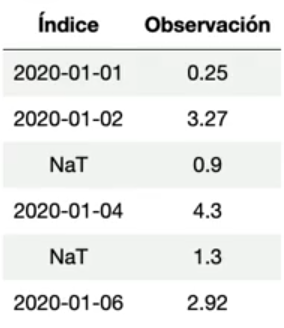

Aquí se tiene que definir un nuevo índice y es el que se le pone a los valores del DataFrame existente

In [30]:
ind = ['2020-01-01', '2020-01-02', 'NaT', '2020-01-04', 'NaT', '2020-01-06']
ind = pd.to_datetime(ind)
obs = [0.25, 3.27, 0.9, 4.3, 1.3, 2.92]

df = pd.DataFrame.from_dict(data = {'data' : obs}).set_index(ind)
df

,data
2020-01-01,0.25
2020-01-02,3.27
NaT,0.90
2020-01-04,4.30
NaT,1.30
2020-01-06,2.92


In [32]:
nuevo_idx = pd.date_range(start = df.index.min(), end = df.index.max(), freq = 'D')
print(nuevo_idx)
df_clean = df.set_index(nuevo_idx)
df_clean

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04',
               '2020-01-05', '2020-01-06'],
              dtype='datetime64[us]', freq='D')


,data
2020-01-01,0.25
2020-01-02,3.27
2020-01-03,0.90
2020-01-04,4.30
2020-01-05,1.30
2020-01-06,2.92


### Ejemplo práctico

Realizar el manejo de marcas de tiempo faltantes en el set de datos ***clicks_faltantes_marcas.csv***

In [52]:
df = pd.read_csv('datos/clicks_faltantes_marcas.csv',
                        parse_dates=['fecha'],
                        index_col='fecha')
df

/tmp/ipykernel_9401/3598237679.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('datos/clicks_faltantes_marcas.csv',


,precio,ubicación,clicks
fecha,,,
2008-04-01,43.155647,2,18784.0
2008-04-02,43.079056,1,24738.0
NaT,43.842609,2,15209.0
2008-04-04,43.382794,2,14320.0
2008-04-05,43.941176,1,11974.0
...,...,...,...
2008-08-09,44.182033,1,6716.0
2008-08-10,43.608260,1,9523.0
2008-08-11,43.553363,1,8881.0


Marcas de tiempo faltantes

In [53]:
df.index.isna().sum()

np.int64(2)

Dónde están ubicadas esas marcas de tiempo faltantes

In [54]:
idx_falta = df[pd.isna(df.index)]
idx_falta

,precio,ubicación,clicks
fecha,,,
NaT,43.842609,2,15209.0
NaT,43.995888,2,15214.0


Procesamiento

In [56]:
df_sin_NaT = df[pd.notna(df.index)].sort_index()

rango_fechas = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')

rango_fechas.difference(df_sin_NaT.index)

DatetimeIndex(['2008-04-03', '2008-04-07', '2008-04-09'], dtype='datetime64[us]', freq=None)

Existen 2 NaT en el indice temporal del ***df*** pero en realidad también hay un registro temporal oculto, faltan los dias 3, 7 y 9
- 2 NaT
- 1 oculta

In [58]:
df.iloc[:9, ]

,precio,ubicación,clicks
fecha,,,
2008-04-01,43.155647,2,18784.0
2008-04-02,43.079056,1,24738.0
NaT,43.842609,2,15209.0
2008-04-04,43.382794,2,14320.0
2008-04-05,43.941176,1,11974.0
2008-04-06,44.403936,1,11007.0
NaT,43.995888,2,15214.0
2008-04-08,43.373773,1,11333.0
2008-04-10,43.154738,5,15677.0


Para solucionarlo se deben atender primero los casos NaT y después los ocultos:

1. Crear un índice que resuelva NaT y que no contenfa los valores de indices ocultos
2. Usar ese índice en el dataframe porque es de la misma dimensión
3. Generar un nuevo indice de la mimsa frecuencia del ***df*** para resolver el índice oculto
4. Se va a generar un NaN en las características, pero después se puede imputar

In [61]:
idx_NaT = pd.date_range(start = df.index.min(), end = df.index.max(), freq = 'D')
idx_NaT = idx_NaT[idx_NaT != '2008-04-08']
idx_NaT

DatetimeIndex(['2008-04-01', '2008-04-02', '2008-04-03', '2008-04-04',
               '2008-04-05', '2008-04-06', '2008-04-07', '2008-04-09',
               '2008-04-10', '2008-04-11',
               ...
               '2008-08-04', '2008-08-05', '2008-08-06', '2008-08-07',
               '2008-08-08', '2008-08-09', '2008-08-10', '2008-08-11',
               '2008-08-12', '2008-08-13'],
              dtype='datetime64[us]', length=134, freq=None)

In [65]:
df = df.set_index(idx_NaT)
df.head(10)

,precio,ubicación,clicks
2008-04-01,43.155647,2,18784.0
2008-04-02,43.079056,1,24738.0
2008-04-03,43.842609,2,15209.0
2008-04-04,43.382794,2,14320.0
2008-04-05,43.941176,1,11974.0
2008-04-06,44.403936,1,11007.0
2008-04-07,43.995888,2,15214.0
2008-04-09,43.373773,1,11333.0
2008-04-10,43.154738,5,15677.0
2008-04-11,42.921659,2,10792.0


In [67]:
idx_final = pd.date_range(start = df.index.min(), end = df.index.max(), freq = 'D')
idx_final

DatetimeIndex(['2008-04-01', '2008-04-02', '2008-04-03', '2008-04-04',
               '2008-04-05', '2008-04-06', '2008-04-07', '2008-04-08',
               '2008-04-09', '2008-04-10',
               ...
               '2008-08-04', '2008-08-05', '2008-08-06', '2008-08-07',
               '2008-08-08', '2008-08-09', '2008-08-10', '2008-08-11',
               '2008-08-12', '2008-08-13'],
              dtype='datetime64[us]', length=135, freq='D')

In [71]:
df = df.reindex(idx_final)
df.head(10)

,precio,ubicación,clicks
2008-04-01,43.155647,2.0,18784.0
2008-04-02,43.079056,1.0,24738.0
2008-04-03,43.842609,2.0,15209.0
2008-04-04,43.382794,2.0,14320.0
2008-04-05,43.941176,1.0,11974.0
2008-04-06,44.403936,1.0,11007.0
2008-04-07,43.995888,2.0,15214.0
2008-04-08,NaN,NaN,NaN
2008-04-09,43.373773,1.0,11333.0
2008-04-10,43.154738,5.0,15677.0
